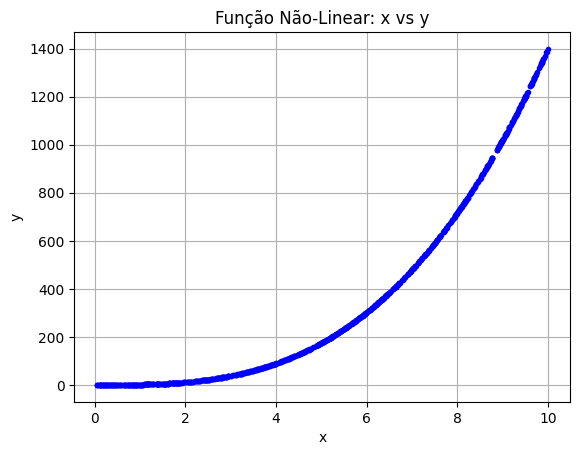

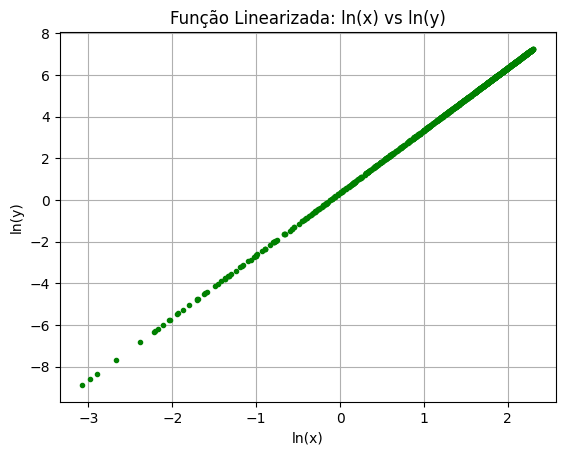

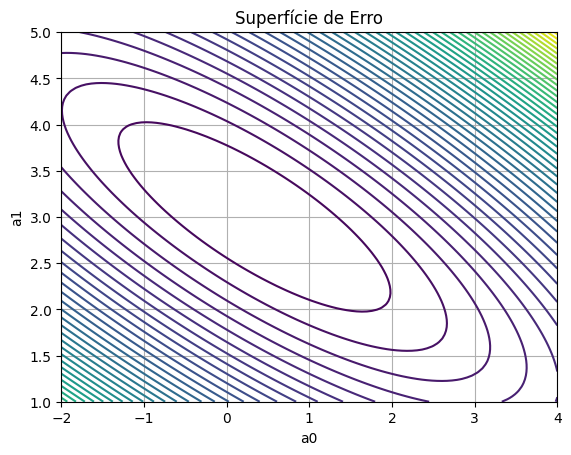

Pesos pela Equação Normal: [0.33647224 3.        ]
Parou em 133 épocas


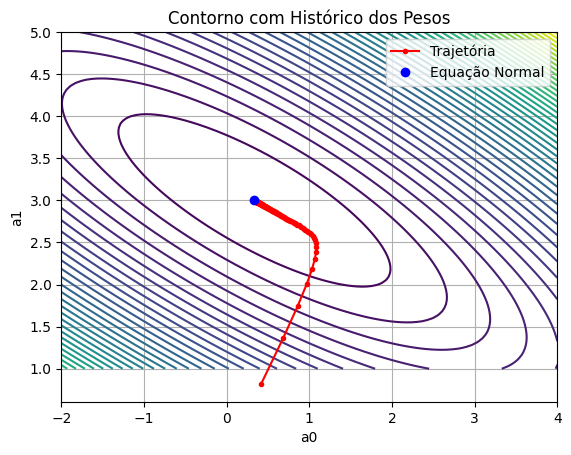

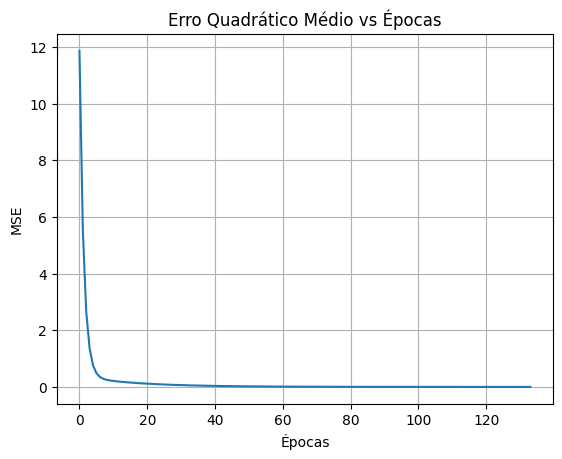

Pesos encontrados pelo Gradiente Descendente: [0.35644602 2.98887442]


In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Configurações iniciais
np.random.seed(42)
M = 1000

# Gerar dados
x = np.random.uniform(0, 10, M)
a0_real = 1.4
a1_real = 3.0
y = a0_real * (x ** a1_real)

# (a) Plotar x vs y
plt.figure()
plt.plot(x, y, 'b.')
plt.title('Função Não-Linear: x vs y')
plt.xlabel('x')
plt.ylabel('y')
plt.grid()
plt.show()

# (b) Linearização
z = np.log(x)
y_lin = np.log(y)

# (c) Plotar z vs y'
plt.figure()
plt.plot(z, y_lin, 'g.')
plt.title('Função Linearizada: ln(x) vs ln(y)')
plt.xlabel('ln(x)')
plt.ylabel('ln(y)')
plt.grid()
plt.show()

def compute_mse(X, Y, a):
    y_pred = X @ a
    mse = np.mean((Y - y_pred) ** 2)
    return mse

def plot_surface(X, Y):
    a0_range = np.linspace(-2, 4, 100)
    a1_range = np.linspace(1, 5, 100)
    A0, A1 = np.meshgrid(a0_range, a1_range)
    MSE_surface = np.zeros_like(A0)

    for i in range(A0.shape[0]):
        for j in range(A0.shape[1]):
            a_tmp = np.array([[A0[i, j]], [A1[i, j]]])
            MSE_surface[i, j] = compute_mse(X, Y, a_tmp)

    return A0, A1, MSE_surface

def train_gde(X, Y, alpha=0.01, max_epochs=1000, tol=0.00001):
    a = np.array([[0.0], [0.0]])
    errors = []
    a0_updates = []
    a1_updates = []
    prev_mse = float('inf')
    consec_count = 0

    for epoch in range(max_epochs):
        y_pred = X @ a
        error = y_pred - Y
        grad = (2/M) * X.T @ error
        a -= alpha * grad

        mse = compute_mse(X, Y, a)
        errors.append(mse)
        a0_updates.append(a[0,0])
        a1_updates.append(a[1,0])

        if abs(mse - prev_mse) < tol:
            consec_count += 1
            if consec_count == 2:
                print(f"Parou em {epoch} épocas")
                break
        else:
            consec_count = 0

        prev_mse = mse

    return a, errors, a0_updates, a1_updates

# Preparar dados linearizados para regressão
Z = np.c_[np.ones(M), z]  # adicionar bias
Y_lin = y_lin.reshape(-1, 1)

# (d.i) Superfície de erro
A0, A1, MSE_surface = plot_surface(Z, Y_lin)

plt.figure()
fig = plt.contour(A0, A1, MSE_surface, levels=50)
plt.title('Superfície de Erro')
plt.xlabel('a0')
plt.ylabel('a1')
plt.grid()
plt.show()

# (d.ii) Solução Analítica (Equação Normal)
a_closed = np.linalg.inv(Z.T @ Z) @ Z.T @ Y_lin
print("Pesos pela Equação Normal:", a_closed.ravel())

# (d.iii) Gradiente Descendente
alpha = 0.05

a_gd, errors_gd, a0_hist, a1_hist = train_gde(Z, Y_lin, alpha)

# (d.iv) Superfície de Contorno com Histórico
plt.figure()
plt.contour(A0, A1, MSE_surface, levels=50)
plt.plot(a0_hist, a1_hist, 'r.-', label='Trajetória')
plt.plot(a_closed[0,0], a_closed[1,0], 'bo', label='Equação Normal')
plt.title('Contorno com Histórico dos Pesos')
plt.xlabel('a0')
plt.ylabel('a1')
plt.legend()
plt.grid()
plt.show()

# (d.v) Erro vs Épocas
plt.figure()
plt.plot(errors_gd)
plt.title('Erro Quadrático Médio vs Épocas')
plt.xlabel('Épocas')
plt.ylabel('MSE')
plt.grid()
plt.show()

# (e) Valores encontrados pelo GD
print("Pesos encontrados pelo Gradiente Descendente:", a_gd.ravel())